In [58]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [59]:
def f(x):
    return np.exp(x[0]) + np.exp(x[1])

In [60]:
def h1(x): return x[0]**2 + x[1]**2 - 9
def g1(x): return x[0] + x[1] - 1
def g2(x): return x[0]
def g3(x): return 5 - x[1]

In [61]:
def penalty_method(x0, eps):
    r = 1.0
    x_curr = np.array(x0)
    history = [x_curr]
    
    while True:
        penalty_func = lambda x: f(x) + r * (
            h1(x)**2 + 
            max(0, -g1(x))**2 + 
            max(0, -g2(x))**2 + 
            max(0, -g3(x))**2
        )
        
        res = minimize(penalty_func, x_curr, method='BFGS')
        x_curr = res.x
        history.append(x_curr)
        
        alpha_x = h1(res.x)**2 + max(0, -g1(res.x))**2 + max(0, -g2(res.x))**2 + max(0, -g3(res.x))**2
        if r * alpha_x < eps:
            return x_curr, f(x_curr), np.array(history)
        r *= 10

In [ ]:
def barrier_method(x0, eps):
    r = 1.0
    x_curr = np.array(x0)
    history = [x_curr]
    
    while True:
        barrier_func = lambda x: f(x) + 1e3 * h1(x)**2 - r * (
            np.log(max(1e-9, g1(x))) + 
            np.log(max(1e-9, g2(x))) + 
            np.log(max(1e-9, g3(x)))
        )
        
        res = minimize(barrier_func, x_curr, method='BFGS')
        x_curr = res.x
        history.append(x_curr)
        
        if r < eps:
            return x_curr, f(x_curr), np.array(history)
        r *= 0.1

In [63]:
cons = [{'type': 'eq', 'fun': h1}, {'type': 'ineq', 'fun': g1}, 
        {'type': 'ineq', 'fun': g2}, {'type': 'ineq', 'fun': g3}]

exact = minimize(f, [2, 1.5], constraints=cons)

start_point = [2.0, 1.5]
x_p, f_p, hist_p = penalty_method(start_point, 0.001)
x_b, f_b, hist_b = barrier_method(start_point, 0.001)

/var/folders/p4/nytp_wt975n3rxtxm6xt9zfw0000gn/T/ipykernel_12552/1433551904.py:9: RuntimeWarning: divide by zero encountered in log
  np.log(max(0, g2(x))) +
/var/folders/p4/nytp_wt975n3rxtxm6xt9zfw0000gn/T/ipykernel_12552/1433551904.py:10: RuntimeWarning: divide by zero encountered in log
  np.log(max(0, g3(x)))
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


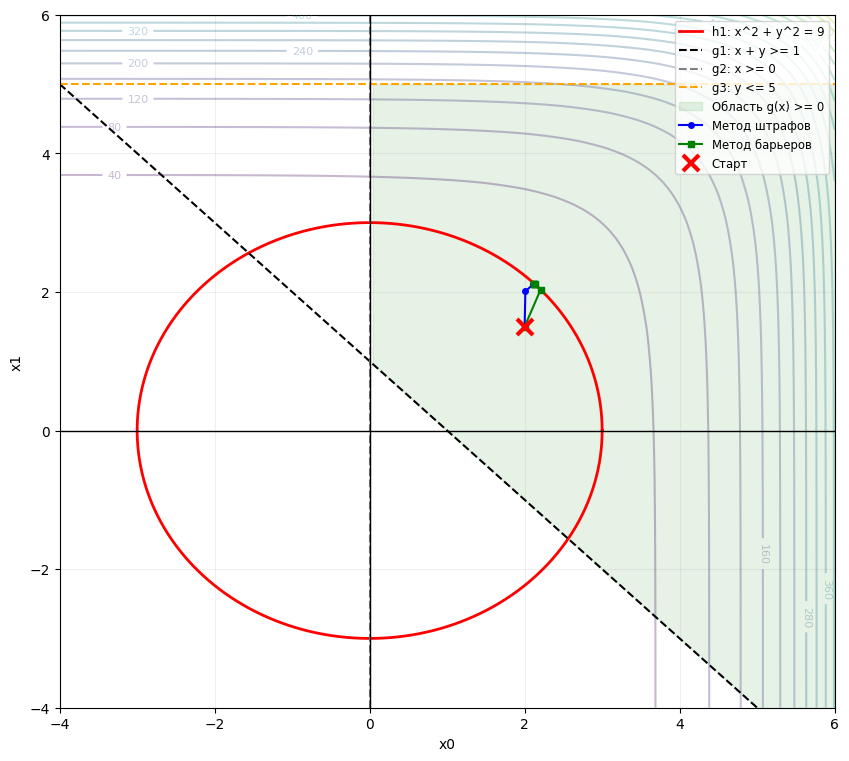

In [64]:
grid_x = np.linspace(-4, 6, 100)
grid_y = np.linspace(-4, 6, 100)
X, Y = np.meshgrid(grid_x, grid_y)
Z = f([X, Y])

plt.figure(figsize=(10, 9))

cp = plt.contour(X, Y, Z, levels=25, cmap='viridis', alpha=0.3)
plt.clabel(cp, inline=True, fontsize=8)

theta = np.linspace(0, 2*np.pi, 200)
plt.plot(3*np.cos(theta), 3*np.sin(theta), 'r-', linewidth=2, label='h1: x^2 + y^2 = 9')
plt.plot(grid_x, 1 - grid_x, 'k--', label='g1: x + y >= 1')
plt.axvline(0, color='gray', linestyle='--', label='g2: x >= 0')
plt.axhline(5, color='orange', linestyle='--', label='g3: y <= 5')

y_g1 = 1 - grid_x
plt.fill_between(grid_x, y_g1, 5, where=(grid_x >= 0), color='green', alpha=0.1, label='Область g(x) >= 0')

plt.plot(hist_p[:, 0], hist_p[:, 1], 'o-', color='blue', markersize=4, label='Метод штрафов')
plt.plot(hist_b[:, 0], hist_b[:, 1], 's-', color='green', markersize=4, label='Метод барьеров')
plt.plot(start_point[0], start_point[1], 'rx', markersize=12, markeredgewidth=3, label='Старт')

plt.xlim(-4, 6)
plt.ylim(-4, 6)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.xlabel('x0')
plt.ylabel('x1')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, alpha=0.2)

plt.show()

In [65]:
print(f"Точное решение: x = {exact.x}, f(x) = {exact.fun:.5f}")
print(f"Метод штрафов:  x = {x_p}, f(x) = {f_p:.5f}")
print(f"Метод барьеров: x = {x_b}, f(x) = {f_b:.5f}")

Точное решение: x = [2.12132028 2.12132027], f(x) = 16.68429
Метод штрафов:  x = [2.12120401 2.12120495], f(x) = 16.68236
Метод барьеров: x = [2.1212139  2.12119506], f(x) = 16.68236
